<a href="https://colab.research.google.com/github/mkweisbr/Portfolio/blob/main/Population_Risk_Queries_SQL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import files

uploaded = files.upload()

Saving clean_population_data.csv to clean_population_data.csv


In [50]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# Load the cleaned CSV
df = pd.read_csv("clean_population_data.csv")

# Connect to SQLite (no installation required)
conn = sqlite3.connect("population.db")

# Push data to SQLite
df.to_sql("population_data", conn, index=False, if_exists="replace")

217

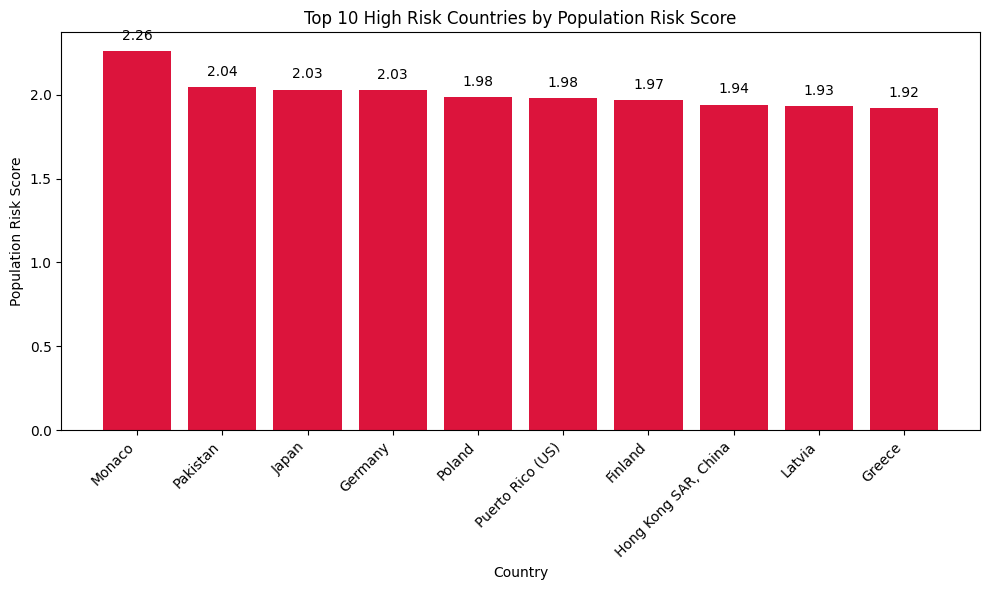

In [51]:
# Top 10 countries with the highest risk
High_Risk_Countries = """
SELECT country, population_risk_score
FROM population_data
ORDER BY population_risk_score DESC
LIMIT 10;
"""
top_risk = pd.read_sql_query(High_Risk_Countries, conn)

# Make the bar chart
plt.figure(figsize=(10,6))
plt.bar(top_risk['country'], top_risk['population_risk_score'], color='crimson')

# Add labels and title
plt.xlabel("Country")
plt.ylabel("Population Risk Score")
plt.title("Top 10 High Risk Countries by Population Risk Score")
plt.xticks(rotation=45, ha='right')  # rotate x labels for readability

# Optional: add value labels on top of bars
for i, score in enumerate(top_risk['population_risk_score']):
    plt.text(i, score + 0.05, round(score, 2), ha='center', va='bottom')

plt.tight_layout()
plt.show()

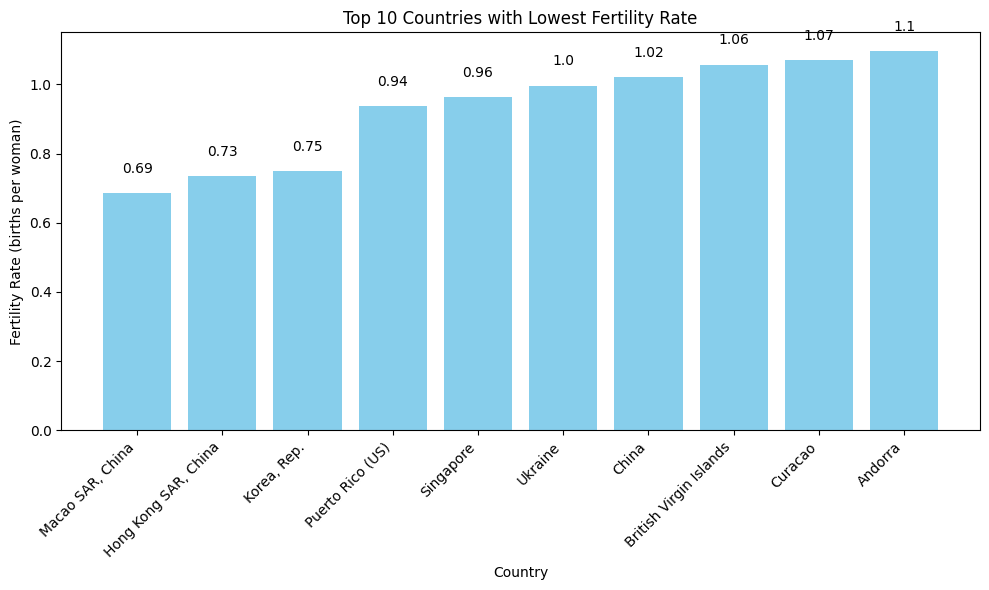

In [53]:
Low_Fertility_Rate = """SELECT country, fertility_rate
FROM population_data
ORDER BY fertility_rate ASC
LIMIT 10;
"""
Low_fertility = pd.read_sql_query(Low_Fertility_Rate, conn)

# Bar chart for the 10 countries with lowest fertility rates
plt.figure(figsize=(10,6))
plt.bar(Low_fertility['country'], Low_fertility['fertility_rate'], color='skyblue')

# Labels and title
plt.xlabel("Country")
plt.ylabel("Fertility Rate (births per woman)")
plt.title("Top 10 Countries with Lowest Fertility Rate")
plt.xticks(rotation=45, ha='right')

# Add values on top of each bar
for i, rate in enumerate(Low_fertility['fertility_rate']):
    plt.text(i, rate + 0.05, round(rate, 2), ha='center', va='bottom')

plt.tight_layout()
plt.show()

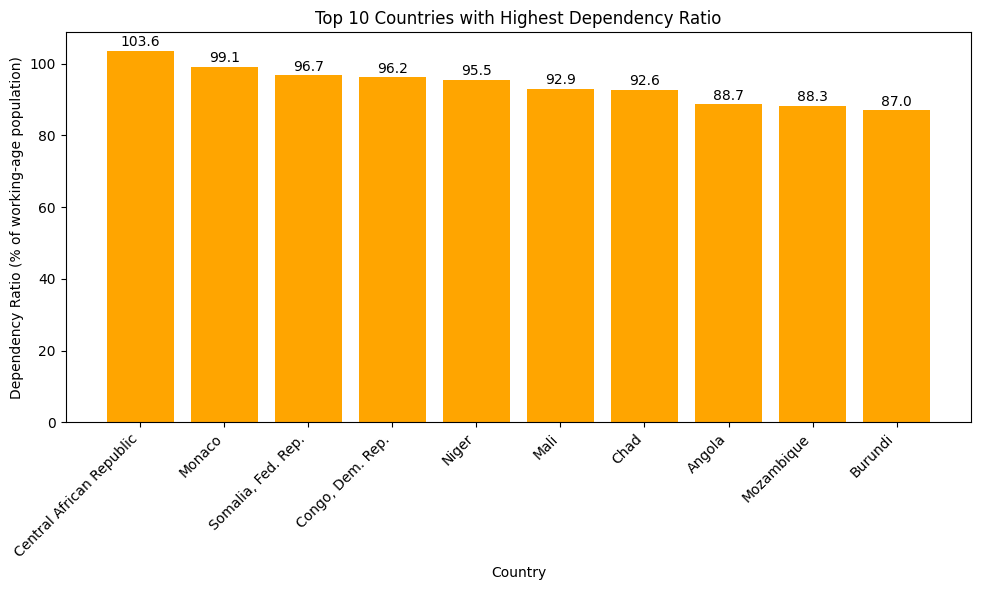

In [54]:
High_Dependency_Ratio = """SELECT country, dependency_ratio
FROM population_data
ORDER BY dependency_ratio DESC
LIMIT 10
"""

High_dependency = pd.read_sql_query(High_Dependency_Ratio, conn)

# Bar chart for countries with highest dependency ratio
plt.figure(figsize=(10,6))
plt.bar(High_dependency['country'], High_dependency['dependency_ratio'], color='orange')

# Labels and title
plt.xlabel("Country")
plt.ylabel("Dependency Ratio (% of working-age population)")
plt.title("Top 10 Countries with Highest Dependency Ratio")
plt.xticks(rotation=45, ha='right')

# Add values on top of bars
for i, ratio in enumerate(High_dependency['dependency_ratio']):
    plt.text(i, ratio + 0.5, round(ratio, 1), ha='center', va='bottom')

plt.tight_layout()
plt.show()

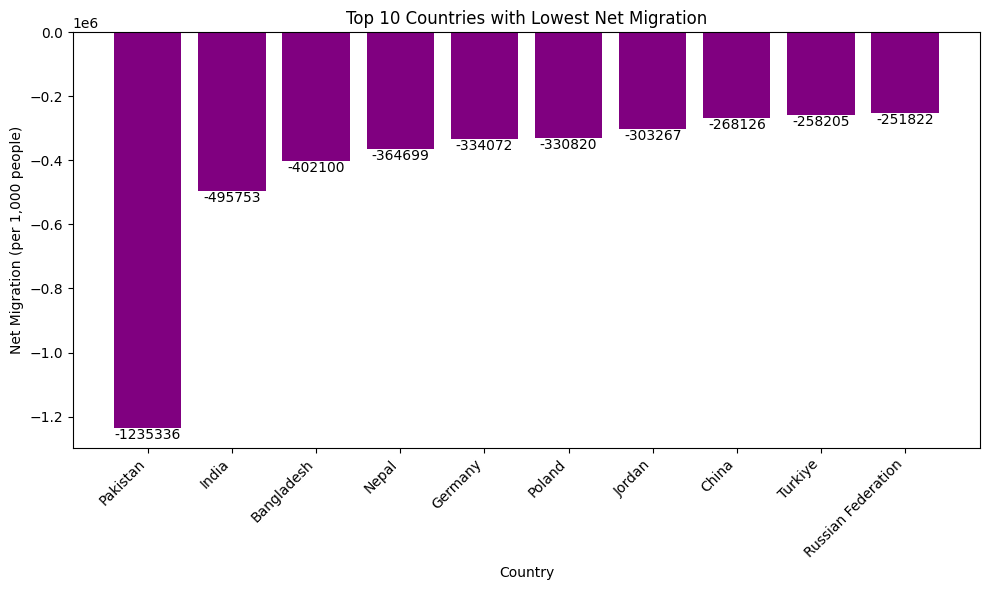

In [55]:
Low_migration = """SELECT country, net_migration
FROM population_data
WHERE net_migration < 0
ORDER BY net_migration ASC
LIMIT 10"""

low_migration = pd.read_sql_query(Low_migration, conn)

# Bar chart for countries with lowest net migration
plt.figure(figsize=(10,6))
plt.bar(low_migration['country'], low_migration['net_migration'], color='purple')

# Labels and title
plt.xlabel("Country")
plt.ylabel("Net Migration (per 1,000 people)")
plt.title("Top 10 Countries with Lowest Net Migration")
plt.xticks(rotation=45, ha='right')

# Add values on top of bars
for i, migration in enumerate(low_migration['net_migration']):
    plt.text(i, migration - 0.5, round(migration, 1), ha='center', va='top')  # negative numbers, so text above bar

plt.tight_layout()
plt.show()

In [22]:
average_population_risk = """
SELECT country, AVG(population_risk_score) AS average_risk
FROM population_data

"""
average_population_risk = pd.read_sql_query(average_population_risk, conn)

print(average_population_risk)

       country  average_risk
0  Afghanistan      1.712265


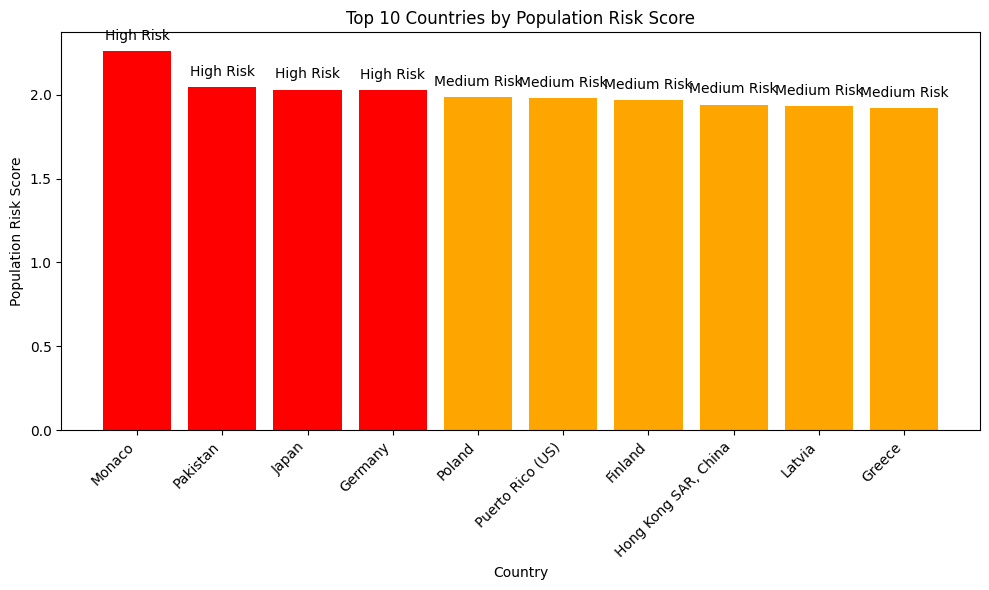

In [56]:
risk_score_categorization = """SELECT country,
       dependency_ratio,
       fertility_rate,
       net_migration,
       population_risk_score,
       CASE
           WHEN population_risk_score >= 2 THEN 'High Risk'
           WHEN population_risk_score >= 1.5 THEN 'Medium Risk'
           ELSE 'Low Risk'
       END AS risk_level
FROM population_data
ORDER BY population_risk_score DESC
LIMIT 10;"""

risk_score_categorization = pd.read_sql_query(risk_score_categorization, conn)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
colors = {'High Risk':'red', 'Medium Risk':'orange', 'Low Risk':'green'}

plt.bar(risk_score_categorization['country'],
        risk_score_categorization['population_risk_score'],
        color=[colors[level] for level in risk_score_categorization['risk_level']])

plt.xlabel("Country")
plt.ylabel("Population Risk Score")
plt.title("Top 10 Countries by Population Risk Score")
plt.xticks(rotation=45, ha='right')

# Add risk level labels above each bar
for i, score in enumerate(risk_score_categorization['population_risk_score']):
    plt.text(i, score + 0.05, risk_score_categorization['risk_level'][i], ha='center', va='bottom')

plt.tight_layout()
plt.show()


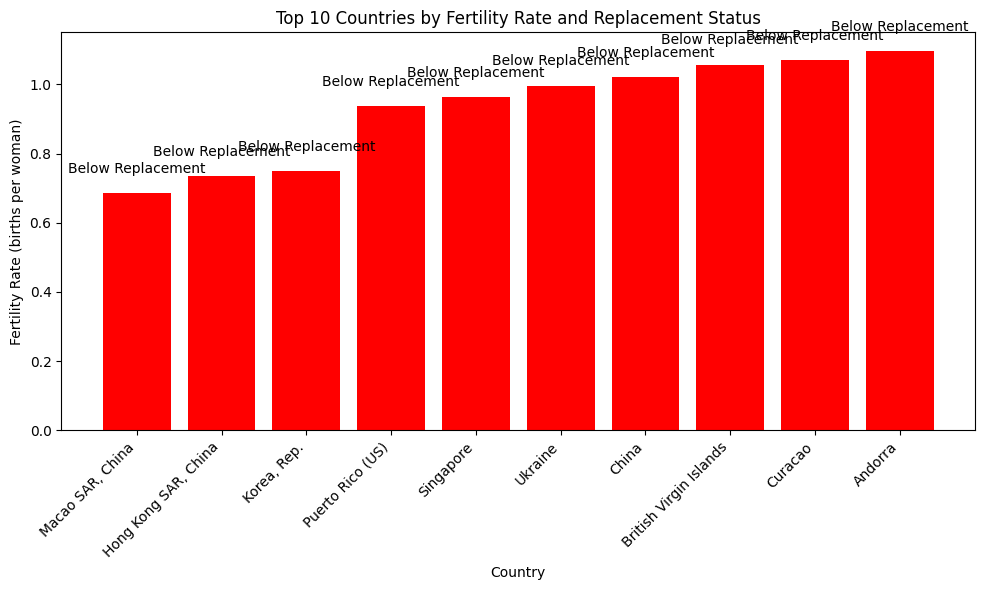

In [59]:
fertility_replacement = """SELECT country,
       fertility_rate,
       CASE WHEN fertility_rate < 2.1 THEN 'Below Replacement' ELSE 'Above Replacement' END AS fertility_status
FROM population_data
ORDER BY fertility_rate ASC
LIMIT 10;"""

fertility_replacement = pd.read_sql_query(fertility_replacement, conn)

# Set colors by status
colors = {'Below Replacement':'red', 'Above Replacement':'green'}

# Bar chart
plt.figure(figsize=(10,6))
plt.bar(fertility_replacement['country'], fertility_replacement['fertility_rate'],
        color=[colors[status] for status in fertility_replacement['fertility_status']])

# Labels and title
plt.xlabel("Country")
plt.ylabel("Fertility Rate (births per woman)")
plt.title("Top 10 Countries by Fertility Rate and Replacement Status")
plt.xticks(rotation=45, ha='right')

# Add status above bars
for i, rate in enumerate(fertility_replacement['fertility_rate']):
    plt.text(i, rate + 0.05, fertility_replacement['fertility_status'][i], ha='center', va='bottom')

plt.tight_layout()
plt.show()

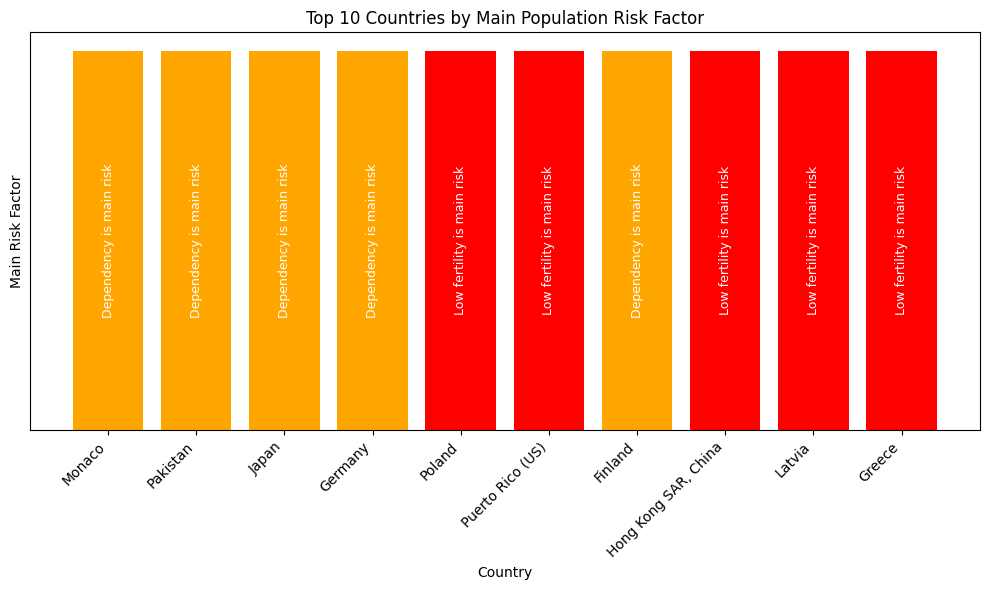

In [60]:
largest_risk = """SELECT country,
       CASE
           WHEN dependency_ratio >= 60 THEN 'Dependency is main risk'
           WHEN fertility_rate < 2.1 THEN 'Low fertility is main risk'
           WHEN net_migration < 0 THEN 'Migration is main risk'
           ELSE 'No single factor dominates'
       END AS main_risk_factor
FROM population_data
ORDER BY population_risk_score DESC
LIMIT 10;"""

largest_risk = pd.read_sql_query(largest_risk, conn)

# Set colors for each risk factor
colors = {
    'Dependency is main risk': 'orange',
    'Low fertility is main risk': 'red',
    'Migration is main risk': 'purple',
    'No single factor dominates': 'green'
}

# Bar chart
plt.figure(figsize=(10,6))
plt.bar(largest_risk['country'], [1]*len(largest_risk),  # uniform height
        color=[colors[factor] for factor in largest_risk['main_risk_factor']])

# Labels and title
plt.xlabel("Country")
plt.ylabel("Main Risk Factor")
plt.title("Top 10 Countries by Main Population Risk Factor")
plt.xticks(rotation=45, ha='right')

# Add text labels on top of bars
for i, factor in enumerate(largest_risk['main_risk_factor']):
    plt.text(i, 0.5, factor, ha='center', va='center', rotation=90, color='white', fontsize=9)

plt.yticks([])  # hide y-axis as it's not meaningful
plt.tight_layout()
plt.show()